# WOE Binning & Feature Selection Walkthrough
**Author:** Anil Jhanwar

Weight of Evidence (WOE) is the standard feature engineering approach for
regulatory scorecards. This notebook demonstrates:
1. Fitting WOE bins for each feature
2. Visualizing WOE monotonicity
3. IV-based feature selection
4. Interpreting the results for an MRM review

In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

_ROOT = Path.cwd()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
os.chdir(_ROOT)
sys.path.insert(0, str(_ROOT))

from src.data_utils import load_data, preprocess, split_data
from src.woe_encoder import WOEBinEncoder

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
df = load_data("data/raw/cs-training.csv")
df_clean = preprocess(df)
X_train, X_val, X_oot, y_train, y_val, y_oot = split_data(df_clean)

2026-05-25 02:31:50,545 | INFO | Loading data from data/raw/cs-training.csv


2026-05-25 02:31:50,706 | INFO |   Loaded 150,000 rows, 11 columns


2026-05-25 02:31:50,706 | INFO |   Target rate: 6.68%


2026-05-25 02:31:50,720 | INFO |   Capped 600 outliers in RevolvingUtilizationOfUnsecuredLines


2026-05-25 02:31:50,720 | INFO |   Capped 14 outliers in age


...

2026-05-25 02:31:50,756 | INFO |   Imputed 29731 missing values in MonthlyIncome with median=5400.00


2026-05-25 02:31:50,762 | INFO |   Imputed 3924 missing values in NumberOfDependents with median=0.00


2026-05-25 02:31:50,879 | INFO |   Train: 105,000 rows (6.68% bad rate)


2026-05-25 02:31:50,879 | INFO |   Val:   22,500 rows  (6.68% bad rate)


2026-05-25 02:31:50,879 | INFO |   OOT:   22,500 rows  (6.68% bad rate)


In [3]:
encoder = WOEBinEncoder(n_bins=10, min_bin_pct=0.05, enforce_monotone=True)
encoder.fit(X_train, y_train)

2026-05-25 02:31:50,889 | INFO |   Binning: RevolvingUtilizationOfUnsecuredLines


2026-05-25 02:31:50,937 | INFO |   Binning: age


2026-05-25 02:31:50,954 | INFO |   Binning: NumberOfTime30-59DaysPastDueNotWorse


2026-05-25 02:31:50,974 | INFO |   Binning: DebtRatio


2026-05-25 02:31:51,022 | INFO |   Binning: MonthlyIncome


...

2026-05-25 02:31:51,089 | INFO |   Binning: NumberOfTimes90DaysLate


2026-05-25 02:31:51,139 | INFO |   Binning: NumberRealEstateLoansOrLines


2026-05-25 02:31:51,170 | INFO |   Binning: NumberOfTime60-89DaysPastDueNotWorse


2026-05-25 02:31:51,190 | INFO |   Binning: NumberOfDependents


2026-05-25 02:31:51,220 | INFO | WOE fitting complete. 10 features processed.


=== Information Value Summary ===
                             feature       iv strength  include
RevolvingUtilizationOfUnsecuredLines 1.001804   Strong     True
             NumberOfTimes90DaysLate 0.839518   Strong     True
NumberOfTime60-89DaysPastDueNotWorse 0.569249   Strong     True
NumberOfTime30-59DaysPastDueNotWorse 0.463121   Strong     True
                                 age 0.248410   Medium     True
     NumberOfOpenCreditLinesAndLoans 0.066868     Weak     True
                       MonthlyIncome 0.062756     Weak     True
                  NumberOfDependents 0.025949     Weak     True
                           DebtRatio 0.018086  Useless    False
        NumberRealEstateLoansOrLines 0.001467  Useless    False


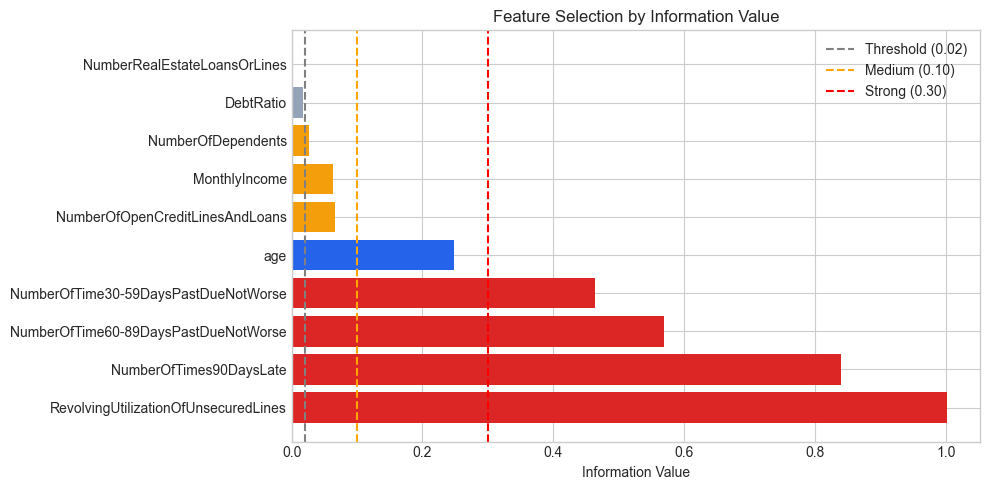

In [4]:
iv_summary = encoder.get_iv_summary(threshold=0.02)
print("=== Information Value Summary ===")
print(iv_summary.to_string(index=False))

# Visualize IV
fig, ax = plt.subplots(figsize=(10, 5))
colors = iv_summary["iv"].apply(lambda x:
    "#DC2626" if x >= 0.3 else "#2563EB" if x >= 0.1 else
    "#F59E0B" if x >= 0.02 else "#94A3B8"
)
ax.barh(iv_summary["feature"], iv_summary["iv"], color=colors)
ax.axvline(0.02, color="gray", linestyle="--", label="Threshold (0.02)")
ax.axvline(0.10, color="orange", linestyle="--", label="Medium (0.10)")
ax.axvline(0.30, color="red", linestyle="--", label="Strong (0.30)")
ax.set_xlabel("Information Value")
ax.set_title("Feature Selection by Information Value")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/woe_iv_summary.png", dpi=150)

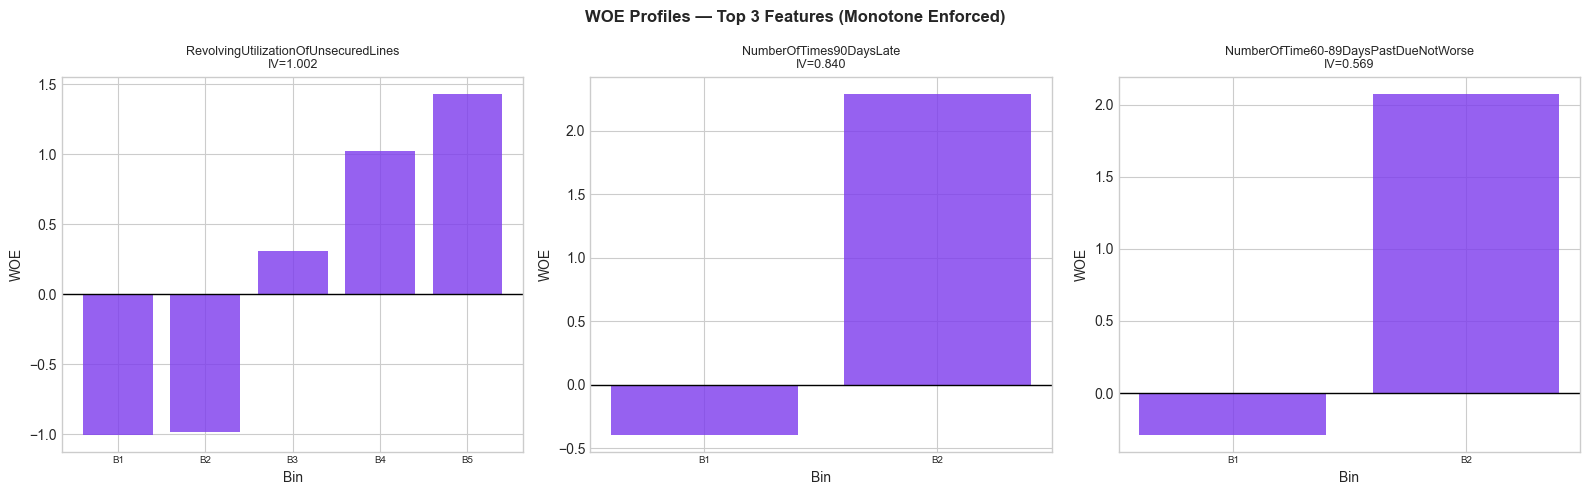

In [5]:
top_features = iv_summary.head(3)["feature"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, feature in enumerate(top_features):
    bt = encoder.get_bin_table(feature)
    bt_clean = bt[bt["bin"] != "MISSING"]
    axes[i].bar(range(len(bt_clean)), bt_clean["woe"], color="#7C3AED", alpha=0.8)
    axes[i].axhline(0, color="black", lw=1)
    axes[i].set_title(f"{feature}\nIV={encoder.iv_[feature]:.3f}", fontsize=9)
    axes[i].set_xlabel("Bin")
    axes[i].set_ylabel("WOE")
    axes[i].set_xticks(range(len(bt_clean)))
    axes[i].set_xticklabels(
        [f"B{j+1}" for j in range(len(bt_clean))], fontsize=7
    )

plt.suptitle("WOE Profiles — Top 3 Features (Monotone Enforced)", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/woe_bin_profiles.png", dpi=150)

In [6]:
top_feature = top_features[0]
print(f"\n=== Full Bin Table: {top_feature} ===")
bt = encoder.get_bin_table(top_feature)
print(bt[["bin", "count", "events", "event_rate", "woe", "iv_contribution"]].to_string(index=False))


=== Full Bin Table: RevolvingUtilizationOfUnsecuredLines ===
            bin  count  events  event_rate       woe  iv_contribution
 (-inf, 0.0029]  10500     269    0.025619 -1.002161         0.066230
0.0029 to 0.444  63000    1646    0.026127 -0.982007         0.384590
 (0.444, 0.697]  10500     933    0.088857  0.308636         0.010896
  (0.697, 0.98]  10500    1746    0.166286  1.024122         0.163292
    (0.98, inf]  10500    2424    0.230857  1.432828         0.376797


In [7]:
X_train_woe = encoder.transform(X_train)
selected = encoder.selected_features(threshold=0.02)
print(f"\nSelected {len(selected)} features for model: {selected}")
print("\nWOE transformed data (first 3 rows):")
print(X_train_woe[selected].head(3))


Selected 8 features for model: ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTime30-59DaysPastDueNotWorse', 'age', 'NumberOfOpenCreditLinesAndLoans', 'MonthlyIncome', 'NumberOfDependents']



WOE transformed data (first 3 rows):
        RevolvingUtilizationOfUnsecuredLines  NumberOfTimes90DaysLate  \
10684                               1.432828                -0.391519   
119331                              1.432828                -0.391519   
24453                              -0.982007                -0.391519   

        NumberOfTime60-89DaysPastDueNotWorse  \
10684                              -0.287169   
119331                             -0.287169   
24453                              -0.287169   

        NumberOfTime30-59DaysPastDueNotWorse       age  \
10684                              -0.254066  0.369086   
119331                             -0.254066  0.005693   
24453                              -0.254066 -0.926653   

        NumberOfOpenCreditLinesAndLoans  MonthlyIncome  NumberOfDependents  
10684                         -0.138590      -0.122402           -0.090496  
119331                         0.538299      -0.122402           -0.090496  
24453      